In [118]:
def load_data(path):
    examples = []
    with open(path,'r') as fp:
        for line in fp:
            sentence_label, sentence = line.strip().lower().split("\t", maxsplit=1)
            examples.append((sentence,sentence_label))

    return examples


train_dataset = load_data("./dataset/train.txt")
dev_dataset = load_data("./dataset/dev.txt")            
test_dataset = load_data("./dataset/test.txt")            

# 打印第一条数据，查看数据格式：(句子，label)
print(train_dataset[0])

('it does seem like this film is polarizing us. you either love it or hate it. i loved it.<br /><br />i agree with the comment(s) that said, you just gotta "feel" this one.<br /><br />also, early in the film, tom cruise shows his girlfriend a painting done by monet--an impressionist painter. monet\'s style is to paint in little dabs so up close the painting looks like a mess, but from a distance, you can tell what the subject is. cruise mentions that the painting has a "vanilla sky". i believe this is a hint to the moviegoer. this movie is like that impressionist painting. it\'s impressionist filmmaking! and it\'s no coincidence that the title of the movie refers to that painting.<br /><br />this is not your typical linear plot. it requires more thought. there is symbolism and there are scenes that jump around and no, you\'re not always going to be sure what\'s going on. but at the end, all is explained.<br /><br />you will need to concentrate on this movie but i think people are makin

In [119]:
import os


def load_dict(path):
    assert os.path.exists(path)
    vocab = {}
    with open(path,"r") as fp:
        f = 0
        for line in fp:
            vocab[line.strip()] = f
            f+=1
    return vocab

word2id_dict= load_dict("./dataset/vocab.txt") 

for idx, (word, word_id) in enumerate(word2id_dict.items()):
    print("word: {}, word_id: {}".format(word, word_id))
    if idx > 7:
        break

word: [PAD], word_id: 0
word: [UNK], word_id: 1
word: the, word_id: 2
word: a, word_id: 3
word: and, word_id: 4
word: of, word_id: 5
word: to, word_id: 6
word: is, word_id: 7
word: in, word_id: 8


In [120]:
from paddle.io import Dataset

class IMDBDataset(Dataset):

    def __init__(self,examples,word2id_dict):
        super().__init__()

        self.word2id_dict = word2id_dict
        self.examples = self.convert_tokens_to_ids(examples)

    def convert_tokens_to_ids(self,examples):
        tmp_examples = []

        for _,example in enumerate(examples):
            seq,label = example
            seq = [self.word2id_dict.get(token,self.word2id_dict['[UNK]']) for token in seq.strip().split(" ")]
            label = int(label)
            tmp_examples.append((seq,label))
        
        return tmp_examples
    
    def __getitem__(self, idx):
        
        return self.examples[idx]
    def __len__(self):
        return len(self.examples)
    

train_set = IMDBDataset(train_dataset, word2id_dict)
dev_set = IMDBDataset(dev_dataset, word2id_dict)
test_set = IMDBDataset(test_dataset, word2id_dict)

print('训练集样本数：', len(train_set))
print('训练集样本数：', len(dev_set))
print('训练集样本数：', len(test_set))
print('样本示例：', train_set[4])
        

训练集样本数： 25000
训练集样本数： 12500
训练集样本数： 12500
样本示例： ([2, 976, 5, 32, 6860, 618, 7673, 8, 2, 13073, 2525, 724, 14, 22837, 18, 164, 416, 8, 10, 24, 701, 611, 1743, 7673, 7, 3, 56391, 21652, 36, 271, 3495, 5, 2, 11373, 4, 13244, 8, 2, 2157, 350, 4, 328, 4118, 12, 48810, 52, 7, 60, 860, 43, 2, 56, 4393, 5, 2, 89, 4152, 182, 5, 2, 461, 7, 11, 7321, 7730, 86, 7931, 107, 72, 2, 2830, 1165, 5, 10, 151, 4, 2, 272, 1003, 6, 91, 2, 10491, 912, 826, 2, 1750, 889, 43, 6723, 4, 647, 7, 2535, 38, 39222, 2, 357, 398, 1505, 5, 12, 107, 179, 2, 20, 4279, 83, 1163, 692, 10, 7, 3, 889, 24, 11, 141, 118, 50, 6, 28642, 8, 2, 490, 1469, 2, 1039, 98975, 24541, 344, 32, 2074, 11852, 1683, 4, 29, 286, 478, 22, 823, 6, 5222, 2, 1490, 6893, 883, 41, 71, 3254, 38, 100, 1021, 44, 3, 1700, 6, 8768, 12, 8, 3, 108, 11, 146, 12, 1761, 4, 92295, 8, 2641, 5, 83, 49, 3866, 5352], 0)


In [121]:
import paddle
from functools import partial

def collate_fn(batch_data, pad_val=0, max_seq_len=256):
    seqs,labels,seq_lens = [],[],[]
    max_len = 0
    for example in batch_data:
        seq,label = example
        seq = seq[:max_seq_len]

        seqs.append(seq)
        seq_lens.append(len(seq))
        max_len = max(max_len,len(seq))
        labels.append(label)

    for i in range(len(seqs)):
        seqs[i] = seqs[i] + [pad_val] * (max_len - len(seqs[i]))
    
    return paddle.to_tensor(seqs),  paddle.to_tensor(labels), paddle.to_tensor(seq_lens)
max_seq_len = 256
batch_size = 128
collate_fn = partial(collate_fn, pad_val=word2id_dict["[PAD]"], max_seq_len=max_seq_len)
train_loader = paddle.io.DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=False, collate_fn=collate_fn)
dev_loader = paddle.io.DataLoader(dev_set, batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate_fn)
test_loader = paddle.io.DataLoader(test_set, batch_size=batch_size, shuffle=False, drop_last=False, collate_fn=collate_fn)

In [122]:
import paddle
from paddle import nn
from paddle.nn import functional
class SentimentClassifier(nn.Layer):
    def __init__(self,input_size,
                 hidden_size,
                 num_embeddings,
                 num_classes=2,
                 num_layers=1,
                 init_scale=0.1,
                 dropout_rate=None):
        super(SentimentClassifier, self).__init__() 
        self.input_size = input_size 
        self.hidden_size = hidden_size
        self.num_embeddings = num_embeddings 
        self.num_classes = num_classes 
        self.num_layers = num_layers 
        self.dropout_rate = dropout_rate 
        self.init_scale = init_scale

        self.embedding = nn.Embedding(num_embeddings=self.num_embeddings,
                                      embedding_dim=self.input_size,
                                      padding_idx=0)
        self.dropout_layer = nn.Dropout(p=self.dropout_rate,mode='upscale_in_train')
        self.lstm_layer = nn.LSTM(input_size=input_size,
                                  hidden_size=hidden_size,
                                  num_layers=num_layers,
                                  )

        self.cls_layer = nn.Linear(self.hidden_size,num_classes)
    def forward(self,inputs, seq_lens=None):
        inputs_emb = functional.relu(self.embedding(inputs))
        if self.dropout_rate is not None and self.dropout_rate > 0.0:
            inputs_emb = self.dropout_layer(inputs_emb)
        _, (hidden_states, _) = self.lstm_layer(inputs_emb, sequence_length=seq_lens)
        hidden_states = hidden_states.squeeze(axis=0)
        logits = self.cls_layer(functional.relu(hidden_states))
        return logits
        

In [123]:
from paddle.metric import Accuracy
num_epochs = 10
learning_rate = 0.0001
eval_steps = 50
log_steps = 10
save_dir = "./checkpoints"

# 实例化模型
input_size = 256
hidden_size = 256
num_embeddings = len(word2id_dict)
num_layers = 1
dropout_rate = 0.2
num_classes = 2
model = SentimentClassifier(input_size, hidden_size, num_embeddings, num_classes=num_classes, num_layers=num_layers, dropout_rate=dropout_rate)
optimizer = paddle.optimizer.Adam(learning_rate=learning_rate, 
                                  beta1=0.9,
                                  beta2=0.999, 
                                  parameters= model.parameters())
loss_fn = nn.CrossEntropyLoss()
metric = Accuracy()

In [124]:
def evaluate(model,data_loader,metric):
    model.eval()
    metric.reset()
    with paddle.no_grad():
        for data in data_loader:
            inputs, labels, seq_lens = data
            logits = model(inputs, seq_lens)
            correct = metric.compute(logits, labels)
            metric.update(correct)

        dev_score = metric.accumulate() 
    return dev_score



In [125]:
def train(model):
    model.train()
    global_step = 0
    best_score = 0
    train_loss_record = []
    train_score_record = []
    num_training_steps = len(train_loader) * num_epochs
    for epoch in range(num_epochs):
        for  data in train_loader:
            inputs, labels, seq_lens = data

            logits = model(inputs, seq_lens)
            loss = loss_fn(logits, labels) # 默认求mean
            train_loss_record.append((global_step, loss.item()))
            loss.backward()             
            optimizer.step()
            optimizer.clear_grad()
            if global_step % log_steps == 0:
                print(f"[Train] epoch: {epoch}/{num_epochs}, step: {global_step}/{num_training_steps}, loss: {loss.item():.5f}")
            if global_step != 0 and (global_step % eval_steps == 0 or global_step == (num_training_steps-1)):
                dev_score = evaluate(model, dev_loader, metric)
                train_score_record.append((global_step, dev_score))
                model.train()
                if dev_score > best_score:
                    print(f"[Evaluate] best accuracy performence has been updated: {best_score:.5f} --> {dev_score:.5f}")
                    best_score = dev_score
                    save_path = os.path.join(save_dir, "best.pdparams")
                    paddle.save(model.state_dict(), save_path)
                print(f"[Evaluate]  dev score: {dev_score:.5f}") 
            global_step += 1
    
    save_path = os.path.join(save_dir, "final.pdparams")
    paddle.save(model.state_dict(), save_path)
    print("[Train] Training done!")
    return train_loss_record, train_score_record


train_loss_record, train_score_record = train(model)

[Train] epoch: 0/10, step: 0/1960, loss: 0.69329
[Train] epoch: 0/10, step: 10/1960, loss: 0.69289
[Train] epoch: 0/10, step: 20/1960, loss: 0.69363
[Train] epoch: 0/10, step: 30/1960, loss: 0.69301
[Train] epoch: 0/10, step: 40/1960, loss: 0.69247
[Train] epoch: 0/10, step: 50/1960, loss: 0.69294
[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.54152
[Evaluate]  dev score: 0.54152
[Train] epoch: 0/10, step: 60/1960, loss: 0.69352
[Train] epoch: 0/10, step: 70/1960, loss: 0.69298
[Train] epoch: 0/10, step: 80/1960, loss: 0.69279
[Train] epoch: 0/10, step: 90/1960, loss: 0.69235
[Train] epoch: 0/10, step: 100/1960, loss: 0.69343
[Evaluate]  dev score: 0.49472
[Train] epoch: 0/10, step: 110/1960, loss: 0.69261
[Train] epoch: 0/10, step: 120/1960, loss: 0.69466
[Train] epoch: 0/10, step: 130/1960, loss: 0.69303
[Train] epoch: 0/10, step: 140/1960, loss: 0.69111
[Train] epoch: 0/10, step: 150/1960, loss: 0.69048
[Evaluate] best accuracy performence has been updated: 0.5

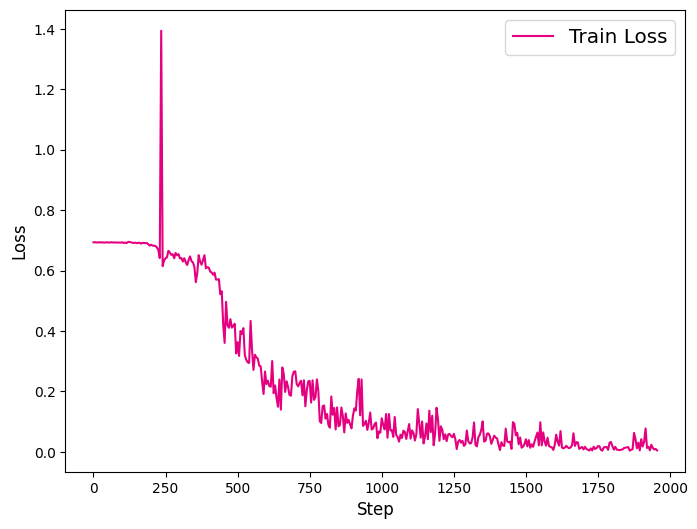

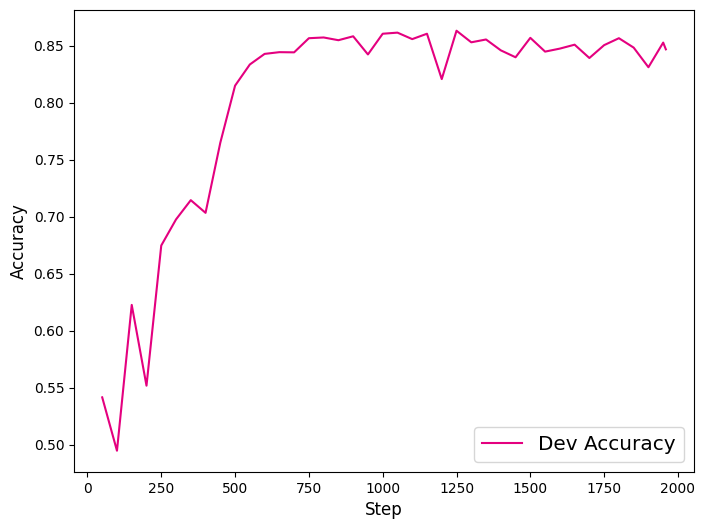

In [126]:
import matplotlib.pyplot as plt

def plot_training_loss(train_loss_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left", acc_legend_loc="lower left"):
    plt.figure(figsize=fig_size)

    train_steps = [x[0] for x in train_loss_record][::sample_step]
    train_losses = [x[1] for x in train_loss_record][::sample_step]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Train Loss")
    #绘制坐标轴和图例
    plt.ylabel("Loss", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

def plot_training_acc(train_score_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left", acc_legend_loc="lower left"):
    plt.figure(figsize=fig_size)

    train_steps=[x[0] for x in train_score_record]
    train_losses = [x[1] for x in train_score_record]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Dev Accuracy")
    #绘制坐标轴和图例
    plt.ylabel("Accuracy", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

fig_path = "./images/chapter9_loss.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=5)

fig_path = "./images/chapter9_acc.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, loss_legend_loc="lower right")

In [127]:
saved_state = paddle.load("./checkpoints/best.pdparams")
model = SentimentClassifier(input_size, hidden_size, num_embeddings, num_classes=num_classes, num_layers=num_layers, dropout_rate=dropout_rate)
model.load_dict(saved_state)

# 评估模型
evaluate(model, test_loader, metric)

0.86456

In [134]:
def infer(model, text):
    model.eval()
    words = [word2id_dict.get(word, word2id_dict['[UNK]']) for word in text.split(" ")]
    words = paddle.to_tensor(words, dtype="int64").unsqueeze(0)
    logits = model(words, paddle.to_tensor([len(words[0])], dtype="int64"))
    id2label={0:"消极情绪", 1:"积极情绪"}
    max_label_id = paddle.argmax(logits, axis=-1).numpy()[0]
    pred_label = id2label[max_label_id]
    print("Label: ", pred_label)

text = "Ricardo is so hot in that bad-boy way."
infer(model, text)

Label:  积极情绪
